## PDF to Image


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# from pathlib import Path
# import random
# from collections import defaultdict
# from config.settings import cfg

# root = cfg.DATA_DIR
# sample_size = 250

# # Lấy danh sách PDF theo folder
# folder_pdfs = {}

# for folder in root.iterdir():
#     if folder.is_dir():
#         pdfs = list(folder.rglob("*.pdf"))
#         folder_pdfs[folder.name] = pdfs

# # Tổng số PDF
# total_pdfs = sum(len(v) for v in folder_pdfs.values())

# selected_files = []

# for folder_name, pdfs in folder_pdfs.items():
#     ratio = len(pdfs) / total_pdfs

#     # số lượng cần lấy theo tỷ lệ
#     n = round(sample_size * ratio)

#     # tránh lấy quá số file hiện có
#     n = min(n, len(pdfs))

#     selected_files.extend(random.sample(pdfs, n))

# print(f"Selected {len(selected_files)} files")
# selected_files

In [3]:
# from config.settings import cfg

# total = 0
# for pdf_path in selected_files:
#     saved = pdf_to_image(pdf_path, cfg.OUTPUT_DATA_DIR)
#     total += len(saved)
#     print("Total file: ", total)


In [4]:
from concurrent.futures import ThreadPoolExecutor
from fipilot.resume_extraction import ResumeExtract

# extractor = ResumeExtract(
#     yolo_model=cfg.YOLO_MODEL,
#     llm_model=cfg.LLM_MODEL,
#     dpi=300,
#     max_workers=cfg.MAX_WORKER,
#     max_retries=cfg.MAX_RETRIES
# )

# pdf_files = sorted(cfg.INPUT_DATA_DIR.rglob("*.pdf"))
# def process_single_pdf(pdf_path):
#     try:
#         saved_files = extractor.pdf_to_images(pdf_path, cfg.OUTPUT_DATA_DIR)
#         print(f"Đã xử lý xong: {pdf_path.name} -> Xuất {len(saved_files)} ảnh.")
#         total_file += 1
#         return saved_files
#     except Exception as e:
#         print(f"❌ Lỗi khi xử lý file {pdf_path.name}: {str(e)}")
#         return []


# with ThreadPoolExecutor(max_workers=cfg.MAX_WORKER) as executor:
#     results = list(executor.map(process_single_pdf, pdf_files))


## Layout Detection 

In [5]:
from concurrent.futures import ThreadPoolExecutor
from fipilot.resume_extraction import ResumeExtract

extractor = ResumeExtract(
    dpi=150,
)

pdf_path = "/home/hoai/user/resource/fipilot/backend/test/1.pdf"
saved_files = extractor.pdf_to_images(pdf_path, "/home/hoai/user/resource/fipilot/backend/test/page_image")
resume_layout = extractor.layout_detection(pdf_path)
resume_layout

{'1_page_1.png': [[27.115671157836914,
   248.68222045898438,
   1253.77783203125,
   1637.529296875],
  [10.904788970947266, 8.884984016418457, 1253.08203125, 210.52035522460938]]}

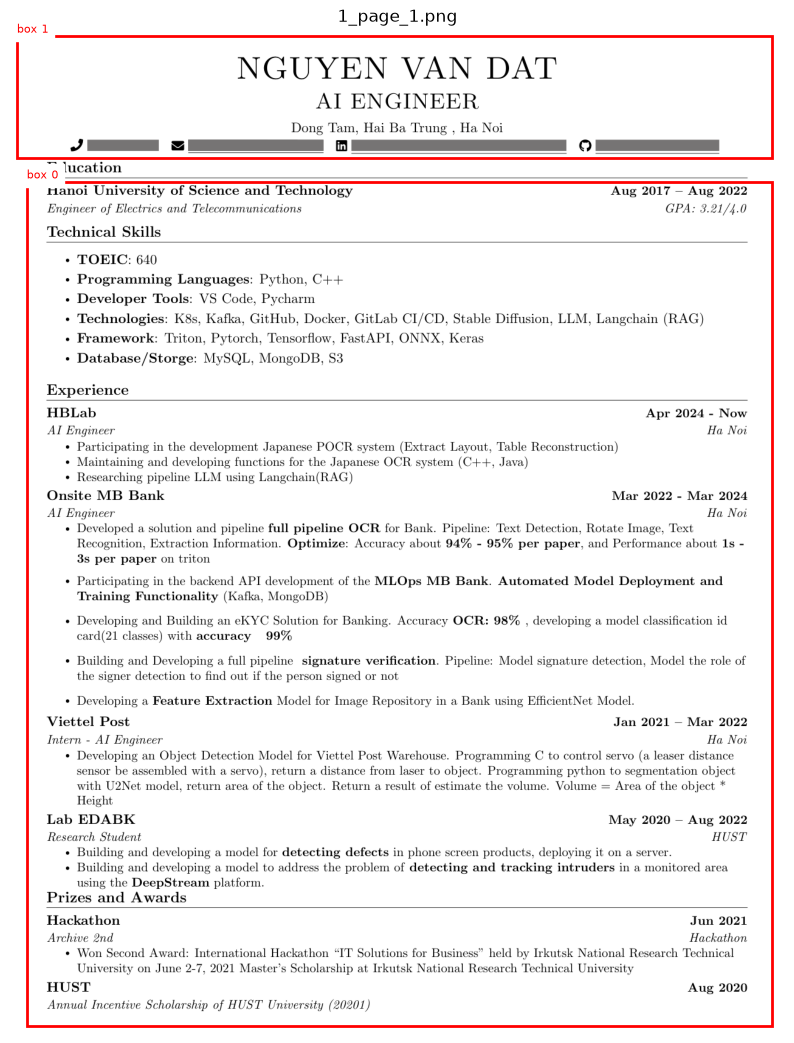

In [6]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

def visualize_layout(image_path, detections: dict, class_names: dict = None):
    """
    image_path: đường dẫn ảnh gốc
    detections: output từ layout_detection(), key là image_name
    class_names: {0: 'header', 1: 'education', ...} — optional
    """
    image_path = Path(image_path)
    xyxy = detections.get(image_path.name)
    
    if xyxy is None:
        print(f"Không tìm thấy detection cho {image_path.name}")
        return

    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(10, 15))
    ax.imshow(img_rgb)

    # xyxy có thể là tensor hoặc numpy
    if hasattr(xyxy, 'cpu'):
        boxes = xyxy.cpu().numpy()
    else:
        boxes = xyxy

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box[:4]
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        label = class_names[i] if class_names else f"box {i}"
        ax.text(x1, y1 - 5, label, color='red', fontsize=8,
                backgroundcolor='white')

    plt.axis("off")
    plt.title(image_path.name)
    plt.show()

for image_path in saved_files:
    visualize_layout(image_path, resume_layout)

In [7]:
all_boxes = extractor.remove_duplicate_boxes(resume_layout)
all_boxes


{'1_page_1.png': [[27.115671157836914,
   248.68222045898438,
   1253.77783203125,
   1637.529296875],
  [10.904788970947266, 8.884984016418457, 1253.08203125, 210.52035522460938]]}

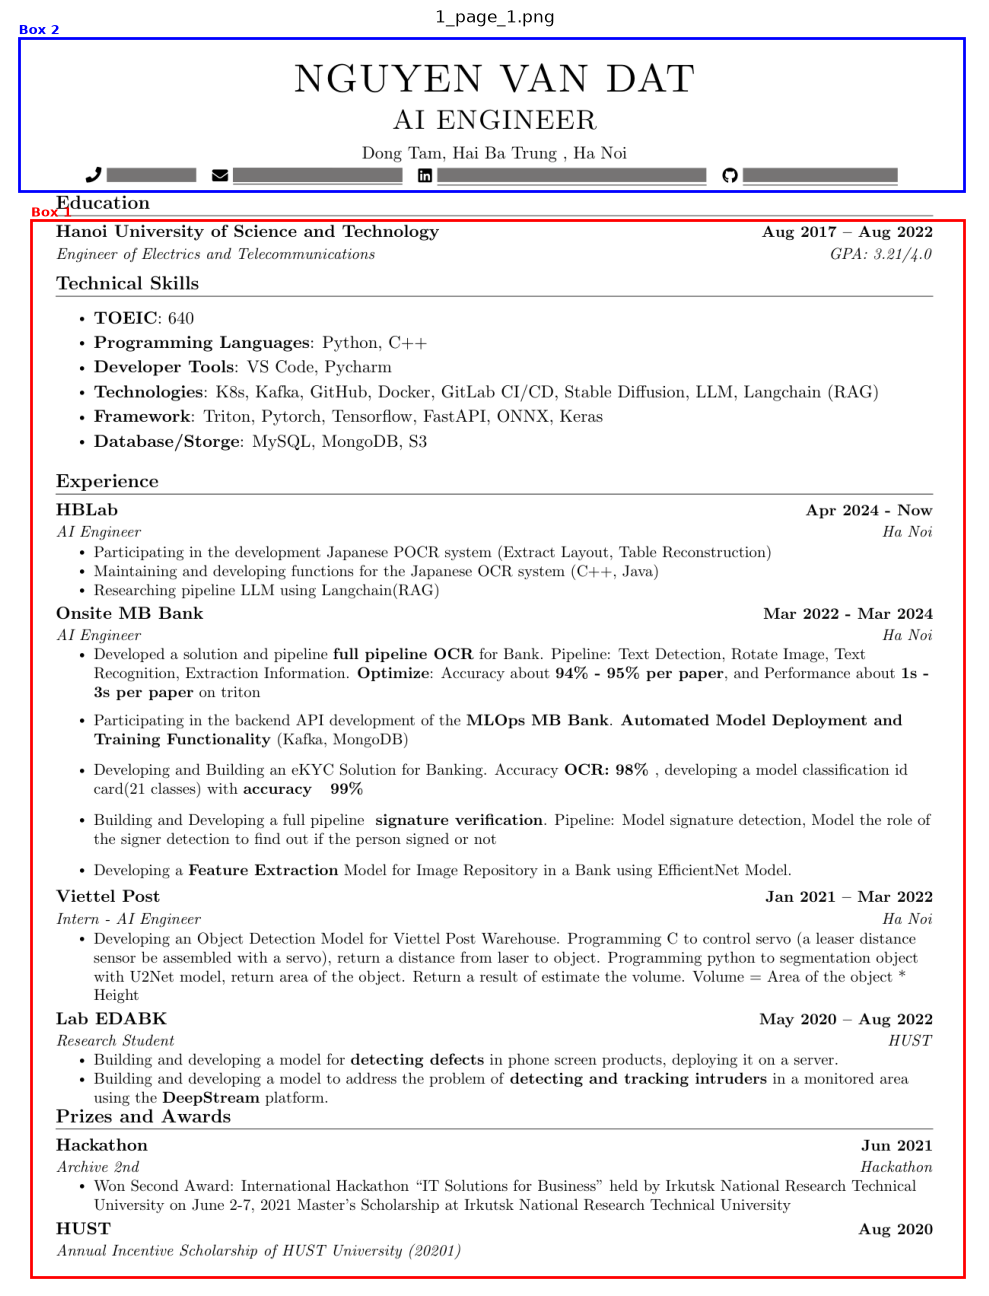

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from pathlib import Path

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

image_dir = {path.name: path for path in saved_files}

for image_name, boxes in all_boxes.items():

    img = mpimg.imread(image_dir[image_name])

    fig, ax = plt.subplots(figsize=(10, 15))
    ax.imshow(img)

    for i, box in enumerate(boxes):

        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=colors[i % len(colors)],
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            max(0, y1 - 5),
            f"Box {i + 1}",
            color=colors[i % len(colors)],
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(image_name)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## Sorting and Map metadata

In [9]:
inter_boxes = extractor.inter_segment_sorting(all_boxes)
inter_boxes

{'1_page_1.png': [[10.904788970947266,
   8.884984016418457,
   1253.08203125,
   210.52035522460938],
  [27.115671157836914, 248.68222045898438, 1253.77783203125, 1637.529296875]]}

In [10]:
resume = extractor.pair_resume(pdf_path)
resume

{'1_page_1.png': [{'bbox': (372.31458028157556,
    28.641716639200848,
    901.2712478637696,
    80.28755187988281),
   'text': 'NGUYEN VAN DAT'},
  {'bbox': (502.1312395731608,
    93.39593251546225,
    771.4808781941732,
    129.27093505859375),
   'text': 'AI ENGINEER'},
  {'bbox': (462.4749819437663,
    150.1115957895915,
    811.0948562622071,
    172.84077008565268),
   'text': 'Dong Tam, Hai Ba Trung , Ha Noi'},
  {'bbox': (265.64165751139325,
    178.805414835612,
    286.3916714986166,
    199.55541292826337),
   'text': '#'},
  {'bbox': (59.99999841054281,
    214.57060178120932,
    183.93548329671225,
    239.48726654052737),
   'text': 'Education'},
  {'bbox': (59.99999841054281,
    253.56351534525555,
    564.5421346028646,
    276.2926737467448),
   'text': 'Hanoi University of Science and Technology'},
  {'bbox': (987.7854029337566,
    255.11029561360678,
    1213.4207407633464,
    275.8603096008301),
   'text': 'Aug 2017 – Aug 2022'},
  {'bbox': (59.999974568684

In [11]:
intra_boxes = extractor.intra_segment_sorting(inter_boxes, resume)
intra_boxes

[{'image': '1_page_1.png',
  'bbox': [10.904788970947266,
   8.884984016418457,
   1253.08203125,
   210.52035522460938],
  'contained_blocks': [{'bbox': (372.31458028157556,
     28.641716639200848,
     901.2712478637696,
     80.28755187988281),
    'text': 'NGUYEN VAN DAT'},
   {'bbox': (502.1312395731608,
     93.39593251546225,
     771.4808781941732,
     129.27093505859375),
    'text': 'AI ENGINEER'},
   {'bbox': (462.4749819437663,
     150.1115957895915,
     811.0948562622071,
     172.84077008565268),
    'text': 'Dong Tam, Hai Ba Trung , Ha Noi'},
   {'bbox': (265.64165751139325,
     178.805414835612,
     286.3916714986166,
     199.55541292826337),
    'text': '#'}]},
 {'image': '1_page_1.png',
  'bbox': [27.115671157836914,
   248.68222045898438,
   1253.77783203125,
   1637.529296875],
  'contained_blocks': [{'bbox': (59.99999841054281,
     253.56351534525555,
     564.5421346028646,
     276.2926737467448),
    'text': 'Hanoi University of Science and Technology'},

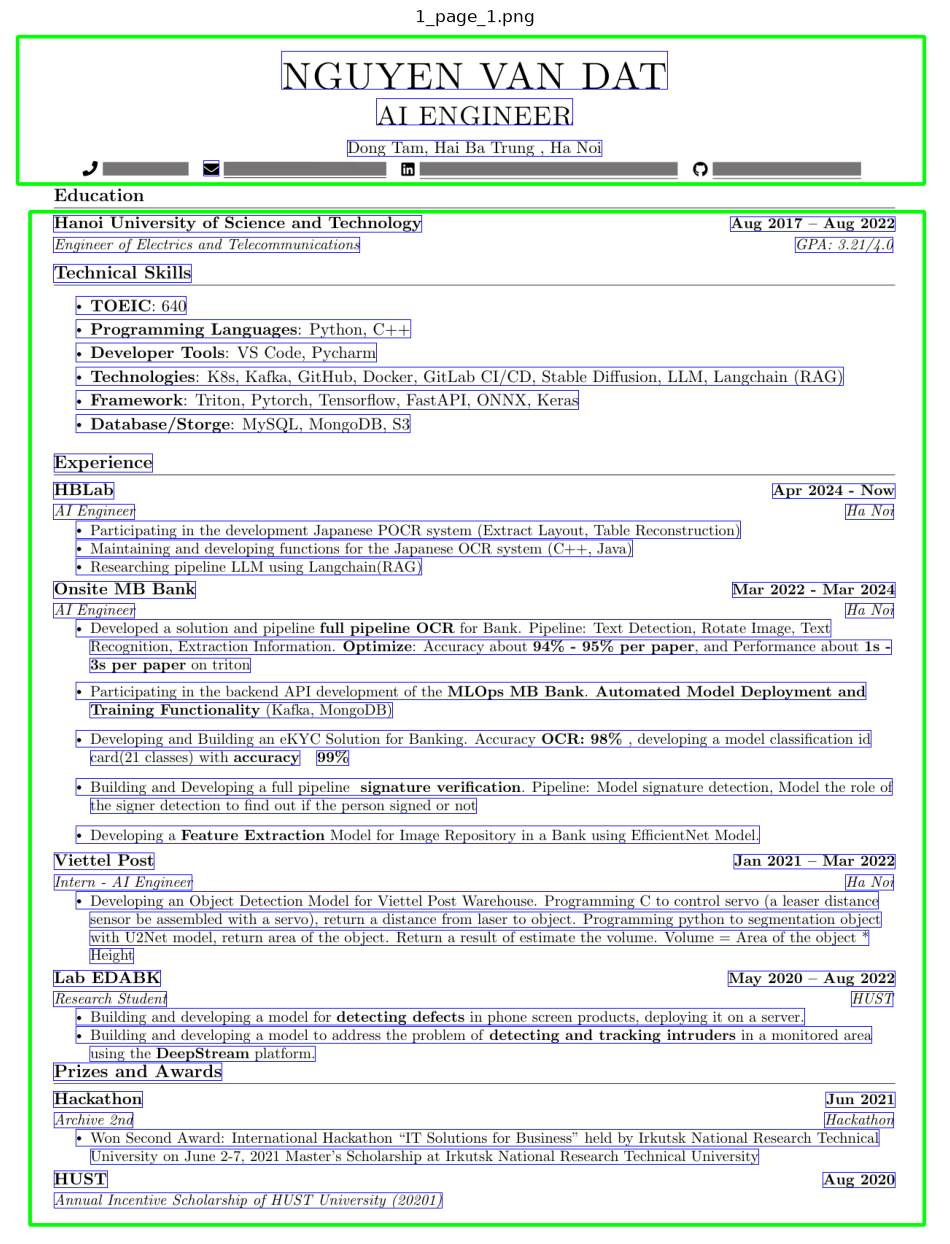

In [12]:
from collections import defaultdict
import cv2
import matplotlib.pyplot as plt

image_lookup = {path.name: path for path in saved_files}

grouped = defaultdict(list)
for region in intra_boxes:
    grouped[region["image"]].append(region)

for image_name, regions in grouped.items():
    img = cv2.imread(str(image_lookup[image_name]))
    
    for region in regions:
        # YOLO bbox (xanh lá)
        x1, y1, x2, y2 = map(int, region["bbox"])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Contained blocks (xanh dương)
        for block in region["contained_blocks"]:
            bx1, by1, bx2, by2 = map(int, block["bbox"])
            cv2.rectangle(img, (bx1, by1), (bx2, by2), (255, 0, 0), 1)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 16))
    plt.title(image_name)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [13]:
linearized_text = extractor.linearize_layout_regions(intra_boxes)
print(linearized_text)

[0]: NGUYEN VAN DAT
[1]: AI ENGINEER
[2]: Dong Tam, Hai Ba Trung , Ha Noi
[3]: #
[4]: Hanoi University of Science and Technology
[5]: Aug 2017 – Aug 2022
[6]: Engineer of Electrics and Telecommunications
[7]: GPA: 3.21/4.0
[8]: Technical Skills
[9]: - TOEIC: 640
[10]: - Programming Languages: Python, C++
[11]: - Developer Tools: VS Code, Pycharm
[12]: - Technologies: K8s, Kafka, GitHub, Docker, GitLab CI/CD, Stable Diffusion, LLM, Langchain (RAG)
[13]: - Framework: Triton, Pytorch, Tensorflow, FastAPI, ONNX, Keras
[14]: - Database/Storge: MySQL, MongoDB, S3
[15]: Experience
[16]: HBLab
[17]: Apr 2024 - Now
[18]: AI Engineer
[19]: Ha Noi
[20]: - Participating in the development Japanese POCR system (Extract Layout, Table Reconstruction)
[21]: - Maintaining and developing functions for the Japanese OCR system (C++, Java)
[22]: - Researching pipeline LLM using Langchain(RAG)
[23]: Onsite MB Bank
[24]: Mar 2022 - Mar 2024
[25]: AI Engineer
[26]: Ha Noi
[27]: - Developed a solution and pipe